# Adaptive Tokenization with Dynamic Vocabulary

This notebook implements and evaluates the proposed adaptive tokenization method.

**Pipeline overview:**
1. Load data (same segments as baseline)
2. Compute embeddings (672-D log-mel, same as Assom)
3. Run `AdaptiveTokenizer` — seed HDBSCAN on full-D embeddings, refine (split/merge/add/prune), BPE
4. Build sequences, compute (a)-(q) features, run classifier
5. Compare against Assom baseline on all metrics

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys, os, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import LabelEncoder

# Make src importable
sys.path.insert(0, os.path.abspath('..'))

from src.data import (
    load_annotations, load_segments, dynamic_segmentation, iqr_filter,
    CONTEXT_DICT,
)
from src.features import compute_spectrograms
from src.tokenizer import AdaptiveTokenizer
from src.sequence import build_sequences, build_feature_matrix, classify_context
from src import eval as ev

logging.basicConfig(level=logging.INFO, format='%(levelname)s %(name)s: %(message)s')

print('Imports OK')

Imports OK


In [2]:
# ── Configuration ──

DATA_DIR = Path('/Volumes/T7/data/raw/fruitbat')
SR = 250_000
RANDOM_STATE = 42

USE_DYNAMIC_SEG = True
DYN_SEG_PARAMS = dict(
    n_fft=1024, hop_length_ms=0.5, win_length_ms=4, ref_level_db=20,
    pre=0.97, min_level_db=-30, silence_threshold=0.1,
    min_silence_for_spec=0.1, max_vocal_for_spec=1.0,
    min_syllable_length_s=0.01, spectral_range=[5000, 60000],
    min_level_db_floor=20, verbose=False,
)

SPEC_TIME = 21
SPEC_FREQ = 32

# Adaptive tokenizer
AT_PCA_DIM = 50
AT_MIN_CLUSTER_SIZE = 50
AT_MIN_SAMPLES = 10
AT_REFINE_MAX_ITER = 10
AT_SIL_THRESHOLD = 0.0
AT_MIN_SUPPORT_FRAC = 0.005
AT_NOISE_MIN_CLUSTER_SIZE = 15
AT_BPE_MAX_MERGES = 20
AT_BPE_MIN_BIGRAM_COUNT = 10

# Baseline UMAP+HDBSCAN (for comparison)
import umap
import hdbscan
from sklearn.neighbors import KNeighborsClassifier, NeighborhoodComponentsAnalysis
from sklearn.pipeline import Pipeline

UMAP_N_NEIGHBORS = 30
UMAP_MIN_DIST = 0.3
HDBSCAN_MIN_CLUSTER_FRAC = 0.02
HDBSCAN_MIN_SAMPLES = 20
HDBSCAN_EPSILON = 0.1

print('Config OK')

Config OK


## 1. Load Data

In [3]:
df = load_annotations(DATA_DIR)
print(f'Filtered annotations: {len(df)}')
print(f'Contexts: {df.Context_name.value_counts().to_dict()}')

Filtered annotations: 6870
Contexts: {'Isolation': 1545, 'Mating protest': 1348, 'Biting': 1290, 'Feeding': 1077, 'Fighting': 564, 'Threat-like': 534, 'Grooming': 218, 'Kissing': 200, 'Separation': 88, 'Landing': 6}


In [4]:
seg_df = load_segments(df, DATA_DIR)
print(f'Duration stats:')
seg_df['duration_s'].describe()

Loading WAVs:   0%|          | 0/6788 [00:00<?, ?it/s]

Segments loaded: 6870 | skipped: 0
Duration stats:


count    6870.000000
mean        2.126014
std         2.039211
min         0.026364
25%         1.314108
50%         1.445180
75%         2.231612
max        34.311484
Name: duration_s, dtype: float64

In [5]:
if USE_DYNAMIC_SEG:
    seg_df = dynamic_segmentation(seg_df, DYN_SEG_PARAMS)
seg_df = iqr_filter(seg_df)
print(f'Final segment count: {len(seg_df)}')
print(seg_df['context_name'].value_counts())

Dynamic segmentation:   0%|          | 0/6870 [00:00<?, ?it/s]

After dynamic segmentation: 29890 sub-segments | failures: 591
IQR filter: kept 27083 / 29890 (bounds [0.0010s, 0.1378s])
Final segment count: 27083
context_name
Mating protest    7877
Isolation         4913
Fighting          4334
Biting            3191
Feeding           2831
Threat-like       2588
Grooming           620
Kissing            400
Separation         320
Landing              9
Name: count, dtype: int64


## 2. Compute Spectrograms (same as baseline)

In [6]:
%%time
tf_specs = compute_spectrograms(
    seg_df, target_sr=SR, spec_time=SPEC_TIME, spec_freq=SPEC_FREQ,
)
print(f'Spectrogram array: {tf_specs.shape}')

X_flat = tf_specs.reshape(len(tf_specs), -1)
print(f'Flattened shape for tokenizer: {X_flat.shape}')

TF preprocess_model:   0%|          | 0/847 [00:00<?, ?it/s]

Spectrogram array: (27083, 21, 32)
Flattened shape for tokenizer: (27083, 672)
CPU times: user 2min 31s, sys: 31.1 s, total: 3min 2s
Wall time: 1min 7s


In [7]:
# Free audio from seg_df to save memory
if 'audio' in seg_df.columns:
    seg_df = seg_df.drop(columns=['audio', 'sr']).reset_index(drop=True)

## 3. Baseline: UMAP + HDBSCAN (Assom reproduction)

In [8]:
%%time
reducer = umap.UMAP(
    n_components=2, n_neighbors=UMAP_N_NEIGHBORS,
    min_dist=UMAP_MIN_DIST, metric='euclidean',
    random_state=RANDOM_STATE, n_jobs=-1,
)
embedding_2d = reducer.fit_transform(X_flat)
print(f'UMAP embedding: {embedding_2d.shape}')

UMAP embedding: (27083, 2)
CPU times: user 31.2 s, sys: 770 ms, total: 32 s
Wall time: 33.2 s


In [9]:
%%time
N = len(embedding_2d)
mcs_base = max(int(N * HDBSCAN_MIN_CLUSTER_FRAC), 10)
clusterer_base = hdbscan.HDBSCAN(
    min_cluster_size=mcs_base, min_samples=HDBSCAN_MIN_SAMPLES,
    cluster_selection_epsilon=HDBSCAN_EPSILON,
    cluster_selection_method='leaf', prediction_data=True,
).fit(embedding_2d)

base_labels = clusterer_base.labels_
n_base_clusters = len(set(base_labels)) - (1 if -1 in base_labels else 0)
print(f'Baseline HDBSCAN: {n_base_clusters} clusters, '
      f'{(base_labels == -1).sum()} noise ({(base_labels == -1).mean():.1%})')

# NCA reassignment for baseline
def reassign_noise_nca(labels, emb, n_neighbors=30):
    labels_ext = labels.copy()
    ix_good = np.where(labels >= 0)[0]
    ix_noise = np.where(labels == -1)[0]
    if len(ix_noise) == 0 or len(ix_good) < 10:
        return labels_ext
    try:
        pipe = Pipeline([
            ('nca', NeighborhoodComponentsAnalysis(random_state=RANDOM_STATE)),
            ('knn', KNeighborsClassifier(n_neighbors=n_neighbors, n_jobs=-1)),
        ])
        pipe.fit(emb[ix_good], labels[ix_good])
        labels_ext[ix_noise] = pipe.predict(emb[ix_noise])
    except Exception:
        knn = KNeighborsClassifier(n_neighbors=n_neighbors, n_jobs=-1)
        knn.fit(emb[ix_good], labels[ix_good])
        labels_ext[ix_noise] = knn.predict(emb[ix_noise])
    return labels_ext

base_labels_nca = reassign_noise_nca(base_labels, embedding_2d)
print(f'After NCA: {len(set(base_labels_nca))} types')

Baseline HDBSCAN: 21 clusters, 2260 noise (8.3%)
After NCA: 21 types
CPU times: user 4min 55s, sys: 2min 29s, total: 7min 25s
Wall time: 8min 37s


## 4. Adaptive Tokenizer

In [10]:
%%time
tokenizer = AdaptiveTokenizer(
    embeddings=X_flat,
    min_cluster_size=AT_MIN_CLUSTER_SIZE,
    min_samples=AT_MIN_SAMPLES,
    pca_dim=AT_PCA_DIM,
    random_state=RANDOM_STATE,
)
print(tokenizer.summary())

INFO src.tokenizer: Seed: 24 types, 19940 noise points


AdaptiveTokenizer: 24 types, 19940 noise, 27083 segments
  iter 0: |V|=24 (+0s +0a -0m -0p)
CPU times: user 2.92 s, sys: 260 ms, total: 3.18 s
Wall time: 5.86 s


In [11]:
%%time
# Refinement loop: split / merge / add / prune
history = tokenizer.refine(
    max_iter=AT_REFINE_MAX_ITER,
    sil_threshold=AT_SIL_THRESHOLD,
    min_support_frac=AT_MIN_SUPPORT_FRAC,
    noise_min_cluster_size=AT_NOISE_MIN_CLUSTER_SIZE,
)
print(tokenizer.summary())

INFO src.tokenizer: Iter 1: splits=0 merges=3 adds=74 prunes=55  |V|=40
INFO src.tokenizer: Iter 2: splits=4 merges=16 adds=50 prunes=41  |V|=37
INFO src.tokenizer: Iter 3: splits=6 merges=15 adds=35 prunes=31  |V|=32
INFO src.tokenizer: Iter 4: splits=4 merges=13 adds=35 prunes=33  |V|=25
INFO src.tokenizer: Iter 5: splits=2 merges=8 adds=34 prunes=33  |V|=20
INFO src.tokenizer: Iter 6: splits=1 merges=4 adds=28 prunes=27  |V|=18
INFO src.tokenizer: Iter 7: splits=1 merges=6 adds=19 prunes=16  |V|=16
INFO src.tokenizer: Iter 8: splits=2 merges=7 adds=23 prunes=22  |V|=12
INFO src.tokenizer: Iter 9: splits=1 merges=4 adds=23 prunes=22  |V|=10
INFO src.tokenizer: Iter 10: splits=1 merges=2 adds=20 prunes=18  |V|=11


AdaptiveTokenizer: 11 types, 5516 noise, 27083 segments
  iter 8: |V|=12 (+2s +23a -7m -22p)
  iter 9: |V|=10 (+1s +23a -4m -22p)
  iter 10: |V|=11 (+1s +20a -2m -18p)
CPU times: user 45.8 s, sys: 20.6 s, total: 1min 6s
Wall time: 26.8 s


In [12]:
# Assign adaptive labels to seg_df
adaptive_labels = tokenizer.get_labels()
seg_df['syllable_id'] = adaptive_labels

# Build sequences for BPE
from src.sequence import build_sequences
seq_df_adaptive = build_sequences(seg_df)
print(f'Sequences: {len(seq_df_adaptive)}')

# Feed sequences to tokenizer for BPE
tokenizer.set_sequences([list(s) for s in seq_df_adaptive['seq']])

Sequences: 4089


In [13]:
# BPE merge pass
bpe_merges = tokenizer.bpe_merge(
    max_merges=AT_BPE_MAX_MERGES,
    min_bigram_count=AT_BPE_MIN_BIGRAM_COUNT,
)
print(f'BPE merges performed: {len(bpe_merges)}')
for left, right, new_id in bpe_merges:
    print(f'  ({left}, {right}) -> {new_id}')

# Update seq_df with BPE-encoded sequences
seq_df_adaptive['seq'] = [list(s) for s in tokenizer._sequences]
seq_df_adaptive['seq_len'] = seq_df_adaptive['seq'].apply(len)
seq_df_adaptive = seq_df_adaptive[seq_df_adaptive['seq_len'] >= 2].reset_index(drop=True)
print(f'\nFinal sequences after BPE: {len(seq_df_adaptive)}')
print(tokenizer.summary())

INFO src.tokenizer: BPE merge: (-1, -1) -> 487  (count=1331)
INFO src.tokenizer: BPE merge: (380, 380) -> 488  (count=1087)
INFO src.tokenizer: BPE merge: (465, 465) -> 489  (count=1078)
INFO src.tokenizer: BPE merge: (380, -1) -> 490  (count=499)
INFO src.tokenizer: BPE merge: (409, 409) -> 491  (count=426)
INFO src.tokenizer: BPE merge: (464, 464) -> 492  (count=402)
INFO src.tokenizer: BPE merge: (380, 410) -> 493  (count=344)
INFO src.tokenizer: BPE merge: (465, -1) -> 494  (count=325)
INFO src.tokenizer: BPE merge: (380, 464) -> 495  (count=323)
INFO src.tokenizer: BPE merge: (465, 409) -> 496  (count=306)
INFO src.tokenizer: BPE merge: (380, 439) -> 497  (count=266)
INFO src.tokenizer: BPE merge: (410, -1) -> 498  (count=255)
INFO src.tokenizer: BPE merge: (380, 465) -> 499  (count=216)
INFO src.tokenizer: BPE merge: (464, -1) -> 500  (count=216)
INFO src.tokenizer: BPE merge: (439, -1) -> 501  (count=179)
INFO src.tokenizer: BPE merge: (487, -1) -> 502  (count=179)
INFO src.toke

BPE merges performed: 20
  (-1, -1) -> 487
  (380, 380) -> 488
  (465, 465) -> 489
  (380, -1) -> 490
  (409, 409) -> 491
  (464, 464) -> 492
  (380, 410) -> 493
  (465, -1) -> 494
  (380, 464) -> 495
  (465, 409) -> 496
  (380, 439) -> 497
  (410, -1) -> 498
  (380, 465) -> 499
  (464, -1) -> 500
  (439, -1) -> 501
  (487, -1) -> 502
  (380, 466) -> 503
  (409, -1) -> 504
  (410, 410) -> 505
  (465, 464) -> 506

Final sequences after BPE: 3481
AdaptiveTokenizer: 31 types, 5516 noise, 27083 segments
  BPE merges: 20
  iter 8: |V|=12 (+2s +23a -7m -22p)
  iter 9: |V|=10 (+1s +23a -4m -22p)
  iter 10: |V|=11 (+1s +20a -2m -18p)


## 5. Refinement History Visualization

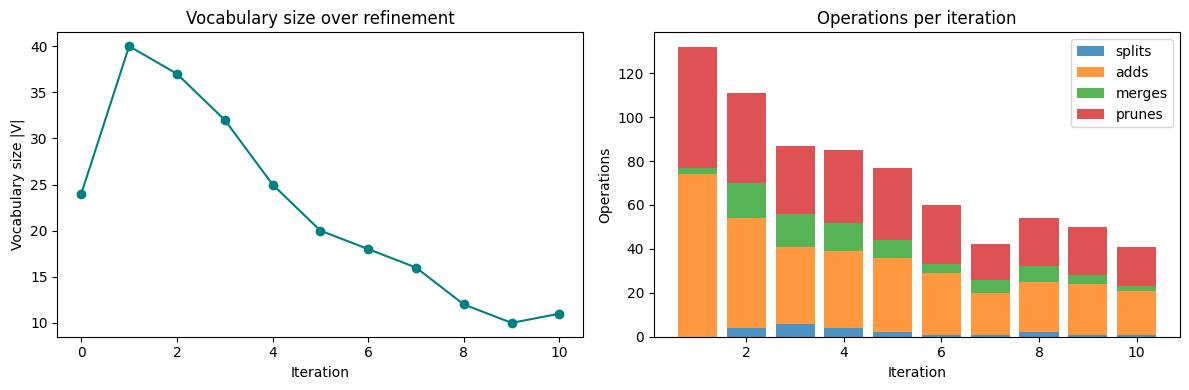

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

iters = [s.iteration for s in history]
sizes = [s.n_types for s in history]
axes[0].plot(iters, sizes, 'o-', color='teal')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Vocabulary size |V|')
axes[0].set_title('Vocabulary size over refinement')

splits = [s.n_splits for s in history[1:]]
merges = [s.n_merges for s in history[1:]]
adds = [s.n_adds for s in history[1:]]
prunes = [s.n_prunes for s in history[1:]]
x = [s.iteration for s in history[1:]]

axes[1].bar(x, splits, label='splits', alpha=0.8)
axes[1].bar(x, adds, bottom=splits, label='adds', alpha=0.8)
axes[1].bar(x, merges, bottom=[s+a for s, a in zip(splits, adds)], label='merges', alpha=0.8)
axes[1].bar(x, prunes, bottom=[s+a+m for s, a, m in zip(splits, adds, merges)], label='prunes', alpha=0.8)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Operations')
axes[1].set_title('Operations per iteration')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. UMAP Visualization (Side-by-Side)

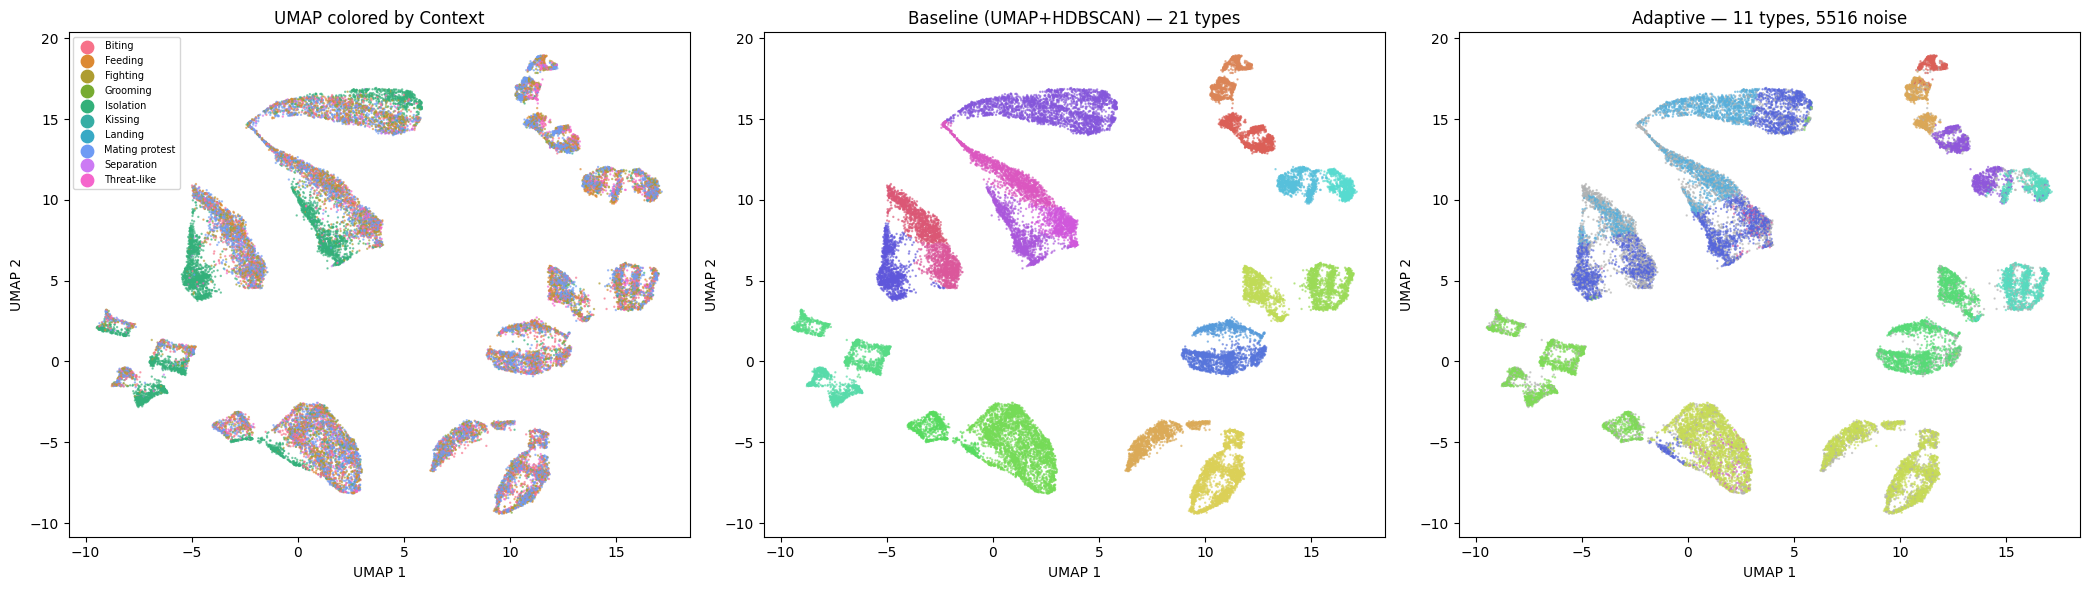

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# 1) Context ground truth
ctx_labels = seg_df['context_name'].values
unique_ctx = sorted(set(ctx_labels))
pal_ctx = sns.color_palette('husl', len(unique_ctx))
color_map_ctx = {c: pal_ctx[i] for i, c in enumerate(unique_ctx)}
colors_ctx = [color_map_ctx[c] for c in ctx_labels]
axes[0].scatter(embedding_2d[:, 0], embedding_2d[:, 1], c=colors_ctx, s=0.5, alpha=0.6)
axes[0].set_title('UMAP colored by Context')
for c in unique_ctx:
    axes[0].scatter([], [], c=[color_map_ctx[c]], label=c, s=20)
axes[0].legend(fontsize=7, markerscale=2, loc='best')

# 2) Baseline HDBSCAN
n_cl_base = max(base_labels_nca) + 1
pal_base = sns.color_palette('hls', n_cl_base)
colors_base = [pal_base[l] for l in base_labels_nca]
axes[1].scatter(embedding_2d[:, 0], embedding_2d[:, 1], c=colors_base, s=0.5, alpha=0.6)
axes[1].set_title(f'Baseline (UMAP+HDBSCAN) — {n_cl_base} types')

# 3) Adaptive tokenizer
at_labels = adaptive_labels.copy()
unique_at = sorted(set(at_labels[at_labels >= 0]))
pal_at = sns.color_palette('hls', len(unique_at))
id_to_color = {uid: pal_at[i] for i, uid in enumerate(unique_at)}
colors_at = [(.7, .7, .7) if l == -1 else id_to_color.get(l, (.5,.5,.5)) for l in at_labels]
axes[2].scatter(embedding_2d[:, 0], embedding_2d[:, 1], c=colors_at, s=0.5, alpha=0.6)
n_at_noise = (at_labels == -1).sum()
axes[2].set_title(f'Adaptive — {len(unique_at)} types, {n_at_noise} noise')

for ax in axes:
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

plt.tight_layout()
plt.show()

## 7. Evaluation: Baseline vs Adaptive

We compare both methods on the full metric suite.

In [16]:
ctx_enc = LabelEncoder().fit_transform(seg_df['context_name'].values)

# Baseline metrics
base_cluster = ev.cluster_quality(embedding_2d, base_labels)
base_alignment = ev.context_alignment(ctx_enc, base_labels_nca)

seg_df_base = seg_df.copy()
seg_df_base['syllable_id'] = base_labels_nca
base_vocab = ev.vocabulary_diagnostics(base_labels_nca, seg_df_base)

seq_df_base = build_sequences(seg_df_base)
base_compress = ev.sequence_compressibility([list(s) for s in seq_df_base['seq']])

print('=== BASELINE ===')
print(f"Clusters: {base_cluster['n_clusters']}")
print(f"Noise fraction: {base_cluster['noise_frac']:.1%}")
print(f"Silhouette: {base_cluster['silhouette']:.3f}")
print(f"ARI (vs context): {base_alignment['ari']:.3f}")
print(f"NMI (vs context): {base_alignment['nmi']:.3f}")
print(f"Vocab size: {base_vocab['vocab_size']}")
print(f"Cross-emitter reuse: {base_vocab['mean_cross_emitter_reuse']:.2f}")
print(f"Compressibility (bits/tok): {base_compress:.2f}")

=== BASELINE ===
Clusters: 21
Noise fraction: 8.3%
Silhouette: 0.535
ARI (vs context): 0.043
NMI (vs context): 0.106
Vocab size: 21
Cross-emitter reuse: 0.91
Compressibility (bits/tok): 3.67


In [17]:
# Adaptive metrics
at_cluster = ev.cluster_quality(X_flat, adaptive_labels)
at_alignment = ev.context_alignment(ctx_enc, adaptive_labels)
at_vocab = ev.vocabulary_diagnostics(adaptive_labels, seg_df)

at_seqs = [list(s) for s in seq_df_adaptive['seq']]
at_compress = ev.sequence_compressibility(at_seqs)

print('=== ADAPTIVE ===')
print(f"Clusters: {at_cluster['n_clusters']}")
print(f"Noise fraction: {at_cluster['noise_frac']:.1%}")
print(f"Silhouette: {at_cluster['silhouette']:.3f}")
print(f"ARI (vs context): {at_alignment['ari']:.3f}")
print(f"NMI (vs context): {at_alignment['nmi']:.3f}")
print(f"Vocab size: {at_vocab['vocab_size']}")
print(f"Cross-emitter reuse: {at_vocab['mean_cross_emitter_reuse']:.2f}")
print(f"Compressibility (bits/tok): {at_compress:.2f}")

=== ADAPTIVE ===
Clusters: 11
Noise fraction: 20.4%
Silhouette: 0.106
ARI (vs context): 0.045
NMI (vs context): 0.073
Vocab size: 12
Cross-emitter reuse: 0.92
Compressibility (bits/tok): 3.59


In [18]:
# Comparison table
comparison = pd.DataFrame({
    'Metric': [
        'Vocabulary size',
        'Noise fraction',
        'Silhouette',
        'ARI (vs context)',
        'NMI (vs context)',
        'Cross-emitter reuse',
        'Compressibility (bits/tok)',
    ],
    'Baseline': [
        base_vocab['vocab_size'],
        f"{base_cluster['noise_frac']:.1%}",
        f"{base_cluster['silhouette']:.3f}",
        f"{base_alignment['ari']:.3f}",
        f"{base_alignment['nmi']:.3f}",
        f"{base_vocab['mean_cross_emitter_reuse']:.2f}",
        f"{base_compress:.2f}",
    ],
    'Adaptive': [
        at_vocab['vocab_size'],
        f"{at_cluster['noise_frac']:.1%}",
        f"{at_cluster['silhouette']:.3f}",
        f"{at_alignment['ari']:.3f}",
        f"{at_alignment['nmi']:.3f}",
        f"{at_vocab['mean_cross_emitter_reuse']:.2f}",
        f"{at_compress:.2f}",
    ],
})
print(comparison.to_string(index=False))

                    Metric Baseline Adaptive
           Vocabulary size       21       12
            Noise fraction     8.3%    20.4%
                Silhouette    0.535    0.106
          ARI (vs context)    0.043    0.045
          NMI (vs context)    0.106    0.073
       Cross-emitter reuse     0.91     0.92
Compressibility (bits/tok)     3.67     3.59


## 8. HP1: Context Classification

In [19]:
# Baseline classification
feat_base = build_feature_matrix(seq_df_base)
res_base = classify_context(seq_df_base, feat_base, random_state=RANDOM_STATE)
print('=== BASELINE HP1 ===')
print(f"F1 original: {res_base['f1_orig']:.3f}  Acc: {res_base['acc_orig']:.3f}")
print(f"F1 permuted: {res_base['f1_perm']:.3f}  Acc: {res_base['acc_perm']:.3f}")
print(f"F1 delta: {res_base['f1_orig'] - res_base['f1_perm']:+.3f}")

=== BASELINE HP1 ===
F1 original: 0.276  Acc: 0.351
F1 permuted: 0.270  Acc: 0.355
F1 delta: +0.006


In [20]:
# Adaptive classification
feat_adaptive = build_feature_matrix(seq_df_adaptive)
res_adaptive = classify_context(seq_df_adaptive, feat_adaptive, random_state=RANDOM_STATE)
print('=== ADAPTIVE HP1 ===')
print(f"F1 original: {res_adaptive['f1_orig']:.3f}  Acc: {res_adaptive['acc_orig']:.3f}")
print(f"F1 permuted: {res_adaptive['f1_perm']:.3f}  Acc: {res_adaptive['acc_perm']:.3f}")
print(f"F1 delta: {res_adaptive['f1_orig'] - res_adaptive['f1_perm']:+.3f}")

=== ADAPTIVE HP1 ===
F1 original: 0.200  Acc: 0.289
F1 permuted: 0.198  Acc: 0.289
F1 delta: +0.003


In [21]:
# Side-by-side F1 comparison
print(f'\n{"Method":<12} {"F1(orig)":<10} {"F1(perm)":<10} {"Delta":<10}')
print(f'{"Baseline":<12} {res_base["f1_orig"]:<10.3f} {res_base["f1_perm"]:<10.3f} '
      f'{res_base["f1_orig"] - res_base["f1_perm"]:+.3f}')
print(f'{"Adaptive":<12} {res_adaptive["f1_orig"]:<10.3f} {res_adaptive["f1_perm"]:<10.3f} '
      f'{res_adaptive["f1_orig"] - res_adaptive["f1_perm"]:+.3f}')


Method       F1(orig)   F1(perm)   Delta     
Baseline     0.276      0.270      +0.006
Adaptive     0.200      0.198      +0.003


## 9. Maximal Repeats & Network Metrics

In [22]:
base_seqs = [list(s) for s in seq_df_base['seq']]
at_seqs = [list(s) for s in seq_df_adaptive['seq']]

mr_base = ev.maximal_repeats_stats(base_seqs)
mr_adapt = ev.maximal_repeats_stats(at_seqs)

print(f'{"":<12} {"Mean MR":<10} {"Max MR":<10} {"Median":<10} {"Total":<10}')
print(f'{"Baseline":<12} {mr_base["mean_mr_len"]:<10.2f} {mr_base["max_mr_len"]:<10} '
      f'{mr_base["median_mr_len"]:<10.1f} {mr_base["total_mr"]}')
print(f'{"Adaptive":<12} {mr_adapt["mean_mr_len"]:<10.2f} {mr_adapt["max_mr_len"]:<10} '
      f'{mr_adapt["median_mr_len"]:<10.1f} {mr_adapt["total_mr"]}')

             Mean MR    Max MR     Median     Total     
Baseline     1.52       6          1.0        6220
Adaptive     1.20       4          1.0        3973


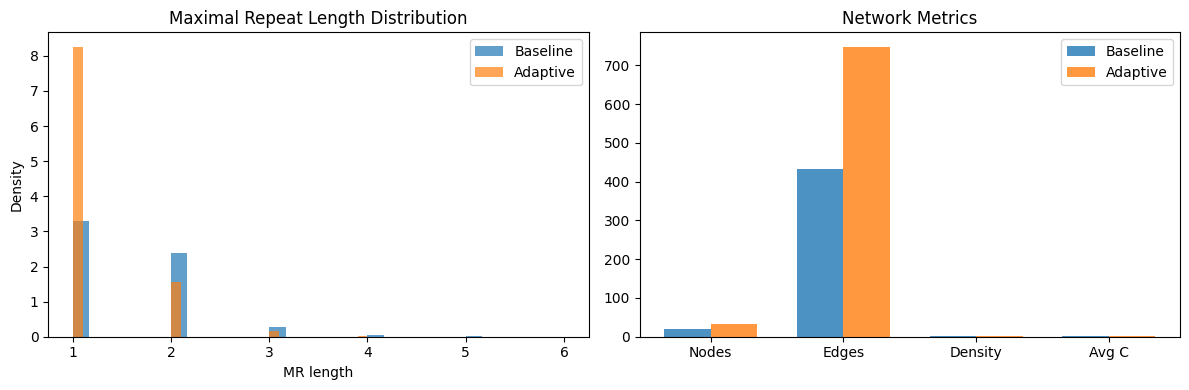

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(mr_base['mr_lengths'], bins=30, alpha=0.7, label='Baseline', density=True)
axes[0].hist(mr_adapt['mr_lengths'], bins=30, alpha=0.7, label='Adaptive', density=True)
axes[0].set_xlabel('MR length')
axes[0].set_ylabel('Density')
axes[0].set_title('Maximal Repeat Length Distribution')
axes[0].legend()

net_base = ev.network_metrics(base_seqs)
net_adapt = ev.network_metrics(at_seqs)

labels_net = ['Nodes', 'Edges', 'Density', 'Avg C']
vals_base = [net_base['nodes'], net_base['edges'], net_base['density'], net_base['avg_clustering']]
vals_adapt = [net_adapt['nodes'], net_adapt['edges'], net_adapt['density'], net_adapt['avg_clustering']]

x_pos = np.arange(len(labels_net))
w = 0.35
axes[1].bar(x_pos - w/2, vals_base, w, label='Baseline', alpha=0.8)
axes[1].bar(x_pos + w/2, vals_adapt, w, label='Adaptive', alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(labels_net)
axes[1].set_title('Network Metrics')
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Summary

In [24]:
print('=' * 60)
print('FINAL COMPARISON')
print('=' * 60)
print(comparison.to_string(index=False))
print()
print(f'{"Method":<12} {"F1(orig)":<10} {"F1(perm)":<10} {"Delta":<10}')
print(f'{"Baseline":<12} {res_base["f1_orig"]:<10.3f} {res_base["f1_perm"]:<10.3f} '
      f'{res_base["f1_orig"] - res_base["f1_perm"]:+.3f}')
print(f'{"Adaptive":<12} {res_adaptive["f1_orig"]:<10.3f} {res_adaptive["f1_perm"]:<10.3f} '
      f'{res_adaptive["f1_orig"] - res_adaptive["f1_perm"]:+.3f}')
print()
print(f'{"":<12} {"Mean MR":<10} {"Compress":<12}')
print(f'{"Baseline":<12} {mr_base["mean_mr_len"]:<10.2f} {base_compress:<12.2f}')
print(f'{"Adaptive":<12} {mr_adapt["mean_mr_len"]:<10.2f} {at_compress:<12.2f}')

FINAL COMPARISON
                    Metric Baseline Adaptive
           Vocabulary size       21       12
            Noise fraction     8.3%    20.4%
                Silhouette    0.535    0.106
          ARI (vs context)    0.043    0.045
          NMI (vs context)    0.106    0.073
       Cross-emitter reuse     0.91     0.92
Compressibility (bits/tok)     3.67     3.59

Method       F1(orig)   F1(perm)   Delta     
Baseline     0.276      0.270      +0.006
Adaptive     0.200      0.198      +0.003

             Mean MR    Compress    
Baseline     1.52       3.67        
Adaptive     1.20       3.59        
